#### Exercise 2: Lab1_4: finite-differences for oppen boundaries

Solve analytically and numerically the **Laplace's equation** for $u(x,y)$ in the dominio $0\leq x \leq L$ and $0\leq y < \infty $, with Dirichlet's boundary conditions:

* u(x,0)=V(x)=f(x) = $u_0\sin(2\pi x/L)$
* u(0,y)=0
* u(L,y)=0
* u(x,$\infty$)=0


To solve numerically the Laplace's equation, set the lenght $L=N\Delta = 100$ and $\Delta=1$ and $u_0=100$.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

La solución analítica del problema se establece como

\begin{equation*}
    u(x,y) = u_0 \sin{ \left( \frac{2\pi x}{L} \right) } \exp{ \left( - \frac{2\pi y}{L} \right) }
\end{equation*}


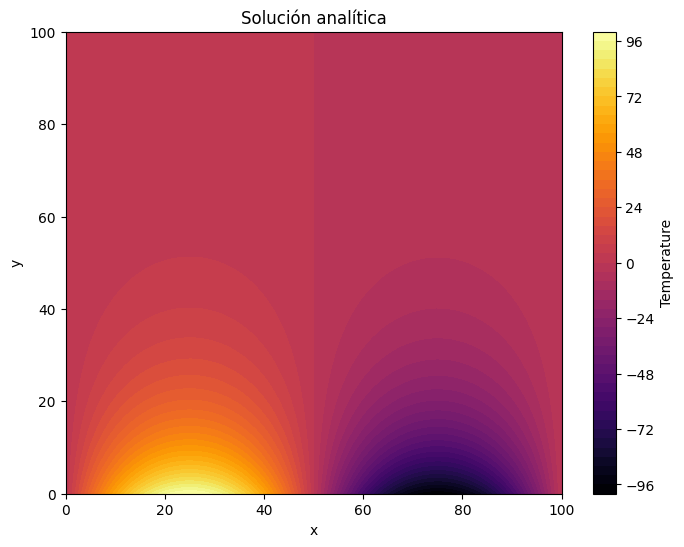

In [7]:
L = 100
u_0 = 100

x = np.linspace(0, L, 100)
y = x

X, Y = np.meshgrid(x, y)
U_analitic = u_0 * np.sin(np.pi * 2 * X / L) * np.exp(- np.pi * 2 * Y / L)

plt.figure(figsize=(8, 6))
plt.contourf(X, Y, U_analitic, levels=50, cmap='inferno')
plt.colorbar(label='Temperature')
plt.title('Solución analítica')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

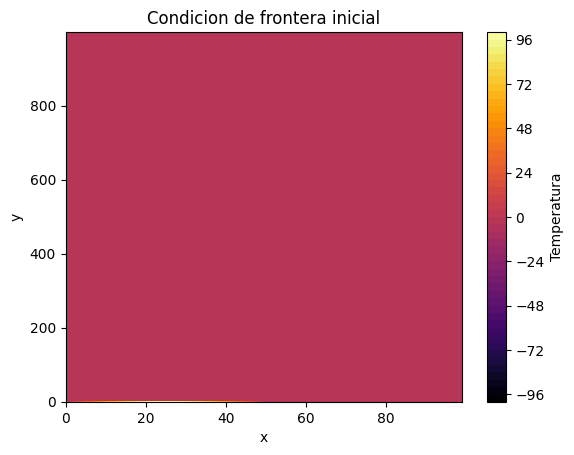

In [8]:
L = 100
N = 100
dx = L / N# Solver LAPLACE Equation:

def solve_laplace_tol_vec(u_0, x, y, tol=1e-6, max_iter=100_000):
    
    u = u_0.copy() 
    u_new = u.copy() 
  
    X, Y = np.meshgrid(x, y) 
    for k in range(max_iter): 
        u_new[1:-1, 1:-1] = 0.25 * ( u[2:, 1:-1] + # abajo 
                                    u[:-2, 1:-1] + # arriba 
                                    u[1:-1, 2: ] + # derecha 
                                    u[1:-1, :-2 ] # izquierda 
                                    ) 
        if np.linalg.norm(u_new - u, ord=np.inf) < tol: 
            print(f"Convergencia alcanzada en {k} iteraciones.") 
            return X, Y, u_new 
        u, u_new = u_new, u
         
    print("No se alcanzó la convergencia dentro del número máximo de iteraciones.") 
    return X, Y, u

u0 = 100

M = 10  # --> Proporcion entre Ly y Lx
Ly = M * L

def f(x):
    return u0 * np.sin(2 * np.pi * x / L)

# Forma de la malla: (ny, nx) = (N*M, N)
# para ser consistente con X, Y = np.meshgrid(x, y)
U_0 = np.zeros((N * M, N))
U_0[0, :] = f(np.linspace(0, L, N))

plt.contourf(U_0, levels=50, cmap='inferno')
plt.colorbar(label='Temperatura')
plt.title('Condicion de frontera inicial')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

Nuestra intuición física nos permite entender que la solución en dirección del eje y debe de ser una exponencial negativa, de modo que decae a cero en el infinito, pero el hecho de que su comportamiento sea exponencial implica que decae rápido, de modo que por haora aproximaremos la solución a una maya $L_x \times L_y$ tal que sea $L_x \times N L_x$ con $N$ puede ser 5 o 6, y haremos que la solución sea cero en ese borde (Un corte abrupto en la simulación)

In [15]:
# Solver LAPLACE Equation:

def solve_laplace_tol_vec(u_0, x, y, tol=1e-12, max_iter=100_000):
    
    u = u_0.copy() 
    u_new = u.copy() 
  
    X, Y = np.meshgrid(x, y) 
    for k in range(max_iter): 
        u_new[1:-1, 1:-1] = 0.25 * ( u[2:, 1:-1] + # abajo 
                                    u[:-2, 1:-1] + # arriba 
                                    u[1:-1, 2: ] + # derecha 
                                    u[1:-1, :-2 ] # izquierda 
                                    ) 
        if np.linalg.norm(u_new - u, ord=np.inf) < tol: 
            print(f"Convergencia alcanzada en {k} iteraciones.") 
            return X, Y, u_new 
        u, u_new = u_new, u
         
    print("No se alcanzó la convergencia dentro del número máximo de iteraciones.") 
    return X, Y, u

Convergencia alcanzada en 24670 iteraciones.


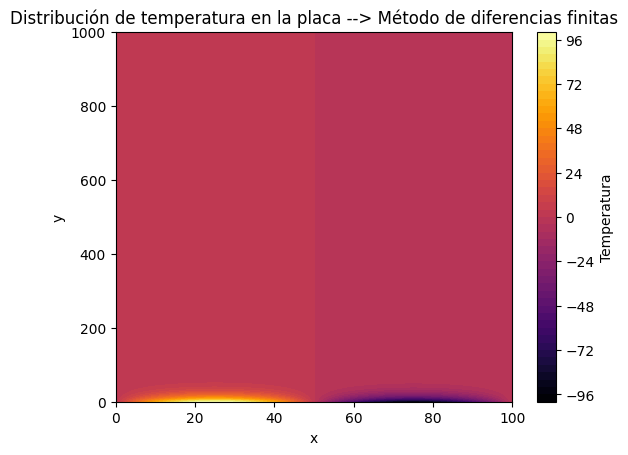

In [16]:
x = np.linspace(0, L, N)
y = np.linspace(0, Ly, N * M)

X, Y, U = solve_laplace_tol_vec(U_0, x, y)

plt.contourf(X, Y, U, levels=50, cmap='inferno')
plt.colorbar(label='Temperatura')
plt.title('Distribución de temperatura en la placa --> Método de diferencias finitas')
plt.xlabel('x')
plt.ylabel('y')
# plt.ylim(0, L)  # Ajustar límites del eje y para mostrar toda la placa
plt.show()

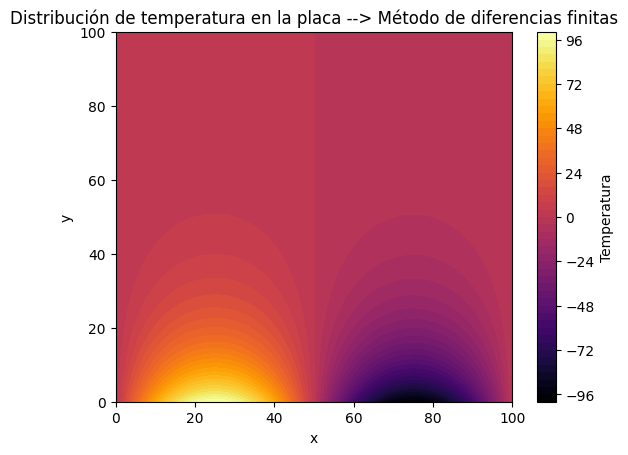

In [17]:

plt.contourf(X, Y, U, levels=50, cmap='inferno')
plt.colorbar(label='Temperatura')
plt.title('Distribución de temperatura en la placa --> Método de diferencias finitas')
plt.xlabel('x')
plt.ylabel('y')
plt.ylim(0, L)  # Ajustar límites del eje y para mostrar toda la placa
plt.show()


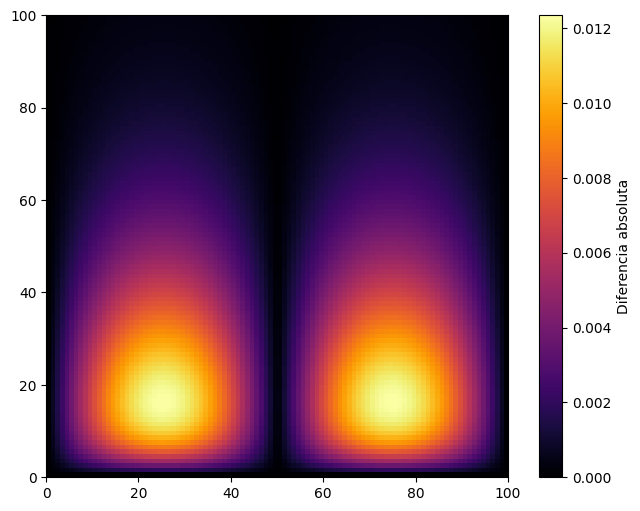

In [18]:
diff = np.abs(U[:100,:] - U_analitic)
plt.figure(figsize=(8, 6))
plt.imshow(diff, extent=(0, L, 0, L), origin='lower', cmap='inferno')
plt.colorbar(label='Diferencia absoluta')    